# Week 7 - Milestone One week

# 1. Lesson: no lesson this week.  Milestone One is due!

# 2. Weekly graph question

Below are the graphs from last week's weekly graph question.  Suppose you wanted to cause the viewer to examine the last three months of data first.  How could you use preattentive attributes to do that?  Suggest several possibilities.

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

C:\Users\Avnish Jadhav\AppData\Local\Temp\ipykernel_31780\2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

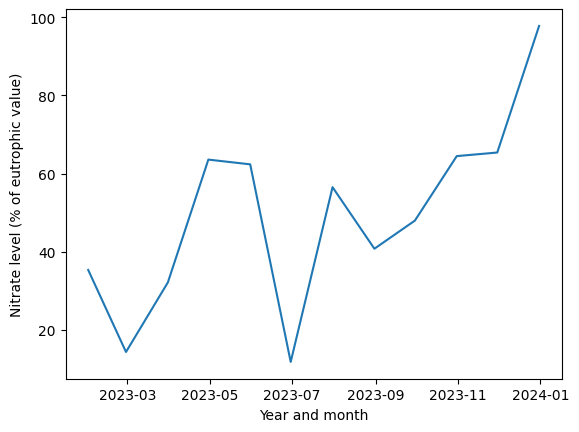

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

C:\Users\Avnish Jadhav\AppData\Local\Temp\ipykernel_31780\1012779568.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

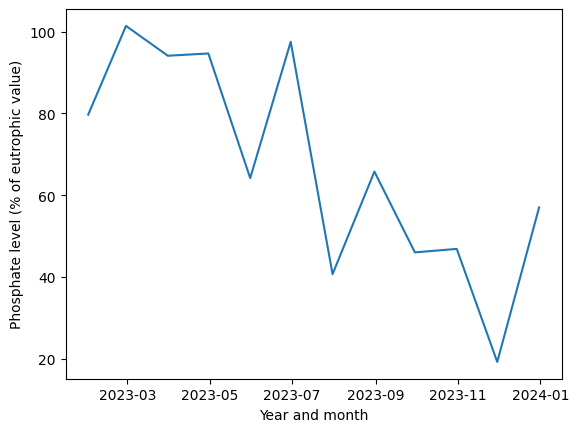

In [3]:
np.random.seed(1)
time_series = 100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

# 3. Working on your datasets

This week, you can work on Milestone One rather than having a particular exercise about working on your datasets

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 99-119 of the Storytelling With Data book as best you can. (The first half of chapter four). You do not have to get the exact data values right, just the overall look and feel.

In [4]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [5]:
files = {
    2018: 'Hospital_Provider_Cost_Report_2018.csv',
    2019: 'Hospital_Provider_Cost_Report_2019.csv',
    2020: 'Hospital_Provider_Cost_Report_2020.csv',
    2021: 'Hospital_Provider_Cost_Report_2021.csv',
    2022: 'Hospital_Provider_Cost_Report_2022.csv',
    2023: 'Hospital_Provider_Cost_Report_2023_updated.csv',
}

frames = []
for yr, f in files.items():
    df_tmp = pd.read_csv(f)
    df_tmp['report_year'] = yr
    frames.append(df_tmp)

df_all = pd.concat(frames, ignore_index=True)
df_all.to_csv('Hospital_Provider_Cost_Report_2018-2023.csv', index=True)

print(f"Combined shape: {df_all.shape}")
df_all.head()

Combined shape: (36560, 118)


,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,...,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges,report_year
0,639197,51994,FERN LODGE INC,18457 MADISON AVE,CASTRO VALLEY,CA,94546-1637,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018
1,644158,341318,CHOWAN HOSPITAL INC.,211 VIRGINIA AVENUE,EDENTON,NC,27932,CHOWAN,99934.0,R,...,1211964.0,7117083.0,NaN,7117083.0,0.342405,7305948.0,17818589.0,38906.0,180387.0,2018
2,644255,102012,SPECIALTY HOSPITAL OF JACKSONVILLE,4901 RICHARD STREET,JACKSONVILLE,FL,32207,DUVAL,27260.0,U,...,35748.0,-1934317.0,-522.0,-1933795.0,NaN,NaN,NaN,NaN,NaN,2018
3,644287,221300,MARTHAS VINEYARD HOSPITAL,ONE HOSPITAL ROAD,OAK BLUFFS,MA,02557,DUKES,99922.0,R,...,5668549.0,59237.0,NaN,59237.0,0.504135,9736097.0,17034508.0,92090.0,174800.0,2018
4,644427,14014,BAYPOINT BEHAVIORAL HEALTH,5750 A SOUTHLAND DRIVE,MOBILE,AL,36693-3316,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018


In [6]:
def show_null_counts_features(df):
    
    count_nulls = df.isnull().sum()
    df_nulls = (df.isnull().mean() * 100).round(2)

    
    feature_types = df.dtypes.apply(
        lambda x: "Numeric" if np.issubdtype(x, np.number) else "Categorical"
    )

    
    missing_data = pd.DataFrame({
        "Feature": count_nulls[count_nulls > 0].index,
        "# Null Values": count_nulls[count_nulls > 0].values,
        "Null %": df_nulls[count_nulls > 0].values,          
        "Type": feature_types[count_nulls > 0].values
    }).sort_values(by="Null %", ascending=False)

    print(f"\nThe dataset contains {len(df):,} samples.\n")

    if len(missing_data) == 0:
        print("There are no null values in the dataset!")
        return

    
    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 200)
    pd.set_option("display.max_colwidth", None)

    
    missing_data = missing_data.reset_index(drop=True)
    missing_data["Null %"] = missing_data["Null %"].map(lambda x: f"{x:.2f}%")

    print(missing_data.to_string(index=False))


show_null_counts_features(df_all)



The dataset contains 36,560 samples.

                                                                Feature  # Null Values  Null %        Type
                                DRG Amounts Other Than Outlier Payments          36560 100.00%     Numeric
                          Hospital Total Days Title V For Adults & Peds          35668  97.56%     Numeric
                    Hospital Total Discharges Title V For Adults & Peds          35627  97.45%     Numeric
                                               Total Discharges Title V          35627  97.45%     Numeric
                                                     Total Days Title V          35578  97.31%     Numeric
                                                       Notes Receivable          35003  95.74%     Numeric
                                                        Unsecured Loans          34698  94.91%     Numeric
                                          Wage-Related Costs (RHC/FQHC)          34243  93.66%     Numeri

In [7]:
# Drop columns that are 100% null across all 6 years
empty_cols = df_all.columns[df_all.isna().mean() == 1.0]
df_clean = df_all.drop(columns=empty_cols)

print(f"Dropped {len(empty_cols)} fully-empty column(s): {empty_cols.tolist()}")
print(f"Remaining columns: {df_clean.shape[1]}")

# Classify columns
exclude_ids = ["rpt_rec_num", "Provider CCN", "Medicare CBSA Number"]
categorical_features = df_clean.select_dtypes(exclude=["number"]).columns.tolist()
numeric_features = [
    c for c in df_clean.select_dtypes(include=["number"]).columns
    if c not in exclude_ids
]

print(f"\nNumeric features to impute: {len(numeric_features)}")
print(f"Categorical features to impute: {len(categorical_features)}")

Dropped 1 fully-empty column(s): ['DRG Amounts Other Than Outlier Payments']
Remaining columns: 117

Numeric features to impute: 104
Categorical features to impute: 10


In [8]:
# Impute numeric with median, categorical with most frequent
df_imputed = df_clean.copy()

num_imputer = SimpleImputer(strategy="median")
df_imputed[numeric_features] = num_imputer.fit_transform(df_imputed[numeric_features])

cat_imputer = SimpleImputer(strategy="most_frequent")
df_imputed[categorical_features] = cat_imputer.fit_transform(df_imputed[categorical_features])

# Drop rows where Medicare CBSA Number is still null
df_imputed = df_imputed.dropna(subset=["Medicare CBSA Number"]).copy()

print(f"Final cleaned dataset: {df_imputed.shape[0]:,} rows x {df_imputed.shape[1]} columns")
show_null_counts_features(df_imputed)

Final cleaned dataset: 36,096 rows x 117 columns

The dataset contains 36,096 samples.

There are no null values in the dataset!


In [9]:
# Map numeric control codes to ownership categories
control_map = {
    1.0: 'Voluntary Nonprofit', 2.0: 'Voluntary Nonprofit',
    3.0: 'Proprietary',         4.0: 'Proprietary',
    5.0: 'Proprietary',         6.0: 'Proprietary',
    7.0: 'Government',          8.0: 'Government',
    9.0: 'Government',          10.0: 'Government',
    11.0: 'Government',         12.0: 'Government',
    13.0: 'Government'
}
df_imputed['Control Type'] = df_imputed['Type of Control'].map(control_map)

# Map CCN facility type codes to readable labels
facility_map = {
    'STH':   'Short-Term Hospital',
    'CAH':   'Critical Access Hospital',
    'PH':    'Psychiatric Hospital',
    'RH':    'Rehabilitation Hospital',
    'LTCH':  'Long-Term Care Hospital',
    'CH':    'Childrens Hospital',
    'ORD':   'ORD Demonstration Hospital',
    'RNMHC': 'Religious Non-Medical Institution'
}
df_imputed['Facility Type Label'] = df_imputed['CCN Facility Type'].map(facility_map)

# Add COVID period flag for later bivariate analysis
df_imputed['COVID Period'] = df_imputed['report_year'].map({
    2018: 'Pre-COVID',
    2019: 'Pre-COVID',
    2020: 'COVID',
    2021: 'COVID',
    2022: 'Post-COVID',
    2023: 'Post-COVID'
})

print("Control Type distribution:")
print(df_imputed['Control Type'].value_counts())
print("\nFacility Type distribution:")
print(df_imputed['Facility Type Label'].value_counts())
print("\nCOVID Period distribution:")
print(df_imputed['COVID Period'].value_counts().reindex(['Pre-COVID','COVID','Post-COVID']))

Control Type distribution:
Control Type
Voluntary Nonprofit    18078
Proprietary            10687
Government              7331
Name: count, dtype: int64

Facility Type distribution:
Facility Type Label
Short-Term Hospital                  19671
Critical Access Hospital              8243
Psychiatric Hospital                  3540
Long-Term Care Hospital               2147
Rehabilitation Hospital               2002
Childrens Hospital                     383
Religious Non-Medical Institution       59
ORD Demonstration Hospital              51
Name: count, dtype: int64

COVID Period distribution:
COVID Period
Pre-COVID     12134
COVID         11960
Post-COVID    12002
Name: count, dtype: int64


In [10]:
# Net Income Margin = Net Income / Net Patient Revenue
df_imputed['Net Income Margin'] = (
    df_imputed['Net Income'] / df_imputed['Net Patient Revenue']
).replace([np.inf, -np.inf], np.nan)

print("Raw margin stats (before clipping):")
print(df_imputed['Net Income Margin'].describe())

df_imputed['Net Income Margin'] = df_imputed['Net Income Margin'].clip(-1.0, 1.0)

print("\nClipped margin stats:")
print(df_imputed['Net Income Margin'].describe())
print(f"\nNull margins remaining: {df_imputed['Net Income Margin'].isna().sum()}")

Raw margin stats (before clipping):
count    3.609600e+04
mean    -1.548081e+03
std      1.933996e+06
min     -1.589017e+08
25%     -3.574101e-02
50%      4.835535e-02
75%      1.378115e-01
max      2.959365e+08
Name: Net Income Margin, dtype: float64

Clipped margin stats:
count    36096.000000
mean         0.022536
std          0.255929
min         -1.000000
25%         -0.035741
50%          0.048355
75%          0.137812
max          1.000000
Name: Net Income Margin, dtype: float64

Null margins remaining: 0



Median Net Income Margin (%) by Year and Facility Type:
Facility Type Label  Critical Access Hospital  Short-Term Hospital
report_year                                                       
2018.0                                   1.85                 4.11
2019.0                                   3.39                 4.41
2020.0                                  10.73                 7.88
2021.0                                  11.05                 6.14
2022.0                                   3.44                 1.07
2023.0                                   4.94                 4.20


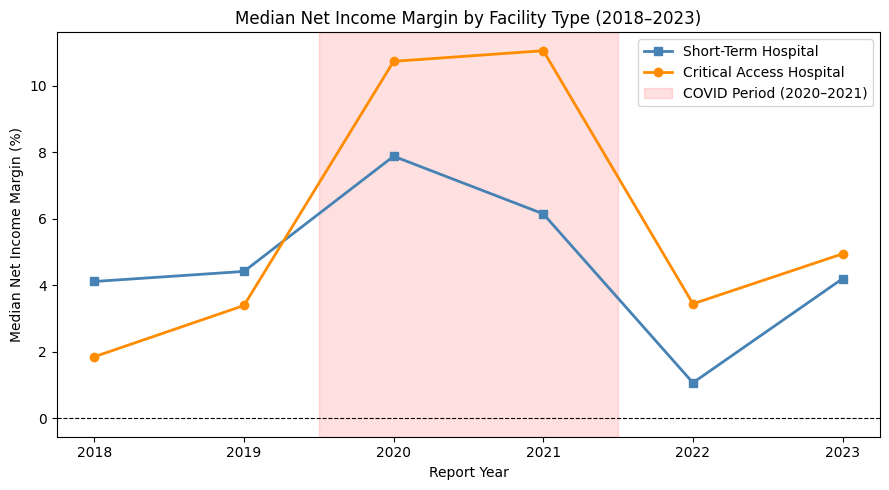

In [13]:
margin_by_year_ft = (
    df_imputed[df_imputed['Facility Type Label'].isin(['Short-Term Hospital', 'Critical Access Hospital'])]
    .groupby(['report_year', 'Facility Type Label'])['Net Income Margin']
    .median()
    .unstack()
) * 100

print("\nMedian Net Income Margin (%) by Year and Facility Type:")
print(margin_by_year_ft.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(margin_by_year_ft.index, margin_by_year_ft['Short-Term Hospital'],
        marker='s', color='steelblue', linewidth=2, label='Short-Term Hospital')
ax.plot(margin_by_year_ft.index, margin_by_year_ft['Critical Access Hospital'],
        marker='o', color='darkorange', linewidth=2, label='Critical Access Hospital')
ax.axvspan(2019.5, 2021.5, alpha=0.12, color='red', label='COVID Period (2020–2021)')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Median Net Income Margin by Facility Type (2018–2023)', fontsize=12)
ax.set_xlabel('Report Year')
ax.set_ylabel('Median Net Income Margin (%)')
ax.set_xticks(margin_by_year_ft.index)
ax.legend()
plt.tight_layout()
plt.show()